# Graph Convolutional Network (late simulations)

In [161]:
batch_size = 8 
data_files = [
    {"label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_0/TRAJ-last75ns.nc"},
    {"label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_1/TRAJ-last75ns.nc"},
    {"label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_2/TRAJ-last75ns.nc"},
    {"label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-last75ns.nc"},
    {"label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-last75ns.nc"},
    {"label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_2/TRAJ-last75ns.nc"}
]
selection_string = "resid 613:754 and name CA N C" #MD2 backbone
epochs = 20
test_size = 0.20
random_state = 42
lr = 0.0001

In [162]:
data_files

[{'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_0/TRAJ-last75ns.nc'},
 {'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_1/TRAJ-last75ns.nc'},
 {'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_2/TRAJ-last75ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-last75ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-last75ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12-TLR4-MDago_monomer/PRODUCTION_2/TRAJ-last75ns.nc'}]

In [173]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch.nn import Embedding, CrossEntropyLoss, Linear, ReLU
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GlobalAttention
from torch_geometric.nn import radius_graph
from torch_geometric.utils import scatter
from sklearn.model_selection import train_test_split

import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import json

## Data Load

In [164]:
# u = mda.Universe("../data/md-2025-03-11/FP11ns.prmtop", "../data/md-2025-03-11/FP11-150ns.nc")
# residue_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('name CA').resnames).tolist()))
# atom_type_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('protein').atoms.types.tolist())))

with open('atom-list.json') as f: 
    atom_type_index = json.load(f)
with open('residue-list.json') as f: 
    residue_index = json.load(f)

In [165]:
def trajectory_to_data(u, selection_string, residue_index, atom_type_index, label):
    for fr in u.trajectory:
        x = torch.from_numpy(u.select_atoms(selection_string).positions)
        residues = list(map(lambda x: residue_index[x], u.select_atoms(selection_string).resnames))
        atom_types = list(map(lambda x: atom_type_index[x], u.select_atoms(selection_string).atoms.types.tolist()))
        d = Data(pos=x, res=torch.tensor(residues, dtype=torch.long), types=torch.tensor(atom_types, dtype=torch.long), label=torch.tensor(label, dtype=torch.long))
        yield d

In [166]:
trj = []

for file in data_files:

    u = mda.Universe(file['topology_filename'], file['coordinates_filename'])
    trj += list(trajectory_to_data(u, selection_string, residue_index, atom_type_index, file['label']))
    print(file['coordinates_filename']) # to check all files are read correctly
    print(len(u.trajectory)) # to check there are 750 frames per file
    
trj[:5]

../FP11_monomer/PRODUCTION_0/TRAJ-last75ns.nc
750
../FP11_monomer/PRODUCTION_1/TRAJ-last75ns.nc
750
../FP11_monomer/PRODUCTION_2/TRAJ-last75ns.nc
750
../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-last75ns.nc
750
../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-last75ns.nc
750
../FP12-TLR4-MDago_monomer/PRODUCTION_2/TRAJ-last75ns.nc
750


[Data(pos=[2244, 3], res=[2244], types=[2244], label=[1]),
 Data(pos=[2244, 3], res=[2244], types=[2244], label=[1]),
 Data(pos=[2244, 3], res=[2244], types=[2244], label=[1]),
 Data(pos=[2244, 3], res=[2244], types=[2244], label=[1]),
 Data(pos=[2244, 3], res=[2244], types=[2244], label=[1])]

## Model

In [167]:
class GCN(torch.nn.Module):
    def __init__(self, radius):
        super().__init__()
        self.radius = radius
        self.embed_res = Embedding(num_embeddings=23, embedding_dim=128)
        self.embed_type = Embedding(num_embeddings=33, embedding_dim=128)
        #
        self.conv1_res = GCNConv(128, 64)
        self.relu1_res = ReLU()
        self.conv2_res = GCNConv(64, 32)
        self.relu2_res = ReLU()
        self.conv3_res = GCNConv(32, 16)
        # 
        self.conv1_type = GCNConv(128, 64)
        self.relu1_type = ReLU()
        self.conv2_type = GCNConv(64, 32)
        self.relu2_type = ReLU()
        self.conv3_type = GCNConv(32, 16)
        # 
        self.linear1 = Linear(32, 2)

    def forward(self, data):
        pos, res, type, batch = data.pos, data.res, data.types, data.batch
        edge_index = radius_graph(pos, r=self.radius, batch=batch)
        #
        z_res = self.embed_res(res)
        z_res = self.conv1_res(z_res, edge_index)
        z_res = self.relu1_res(z_res)
        z_res = self.conv2_res(z_res, edge_index)
        z_res = self.relu2_res(z_res)
        z_res = self.conv3_res(z_res, edge_index)
        #
        z_type = self.embed_type(type)
        z_type = self.conv1_type(z_type, edge_index)
        z_type = self.relu1_type(z_type)
        z_type = self.conv2_type(z_type, edge_index)
        z_type = self.relu2_type(z_type)
        z_type = self.conv3_type(z_type, edge_index)
        #
        z_res = scatter(z_res, data.batch, dim=0, reduce='mean')
        z_type = scatter(z_type, data.batch, dim=0, reduce='mean')
        z = torch.cat([z_res, z_type], dim=1)
        z = self.linear1(z)
        #z = F.softmax(z, dim=1) #CrossEntropyLoss already does softmax at the end
        return z

In [168]:
train_trj, test_trj = train_test_split(trj, test_size=test_size, random_state=random_state)

In [169]:
print(len(train_trj))

3600


In [170]:
print(len(test_trj))

900


In [171]:
rad = [3.0, 5.0, 7.0, 10.0]
results = {}
for r in rad:
    gcn = GCN(radius=r)
    loss = CrossEntropyLoss()
    optimizer = torch.optim.Adam(gcn.parameters(), lr=lr, weight_decay=5e-4)
    train_loader = DataLoader(train_trj, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_trj, batch_size=batch_size, shuffle=True)
    history = []
    print(f"Training for radius {r}:")

    for i in tqdm.tqdm(range(epochs)):
        statistics = dict()
        statistics['training_loss'] = 0.0
        gcn.train()
        for d in train_loader:
            optimizer.zero_grad()
            z = gcn(d)
            l = loss(z, d.label)
            l.backward()
            optimizer.step()
        statistics['training_loss'] += l.item()

        gcn.eval()
        with torch.no_grad():
            statistics['test_accuracy'] = 0.0
            statistics['test_loss'] = 0.0
            for d in test_loader:
                z = gcn(d)
                l = loss(z, d.label)
                a = ((z.argmax(1) == d.label).sum())
                statistics['test_accuracy'] += a.item()
                statistics['test_loss'] += l.item()
                
        statistics['test_accuracy'] /= len(test_trj)
        statistics['test_loss'] /= ((len(test_trj) // batch_size) + 1)

        print(f"Epoch {i+1:2d} | Accuracy {statistics['test_accuracy']:.4f}")
        history.append(statistics)
        
    print(f"================================")
    results[r] = history

Training for radius 3.0:


  5%|█████▊                                                                                                             | 1/20 [01:36<30:26, 96.13s/it]

Epoch  1 | Accuracy 0.4956


 10%|███████████▌                                                                                                       | 2/20 [03:12<28:48, 96.02s/it]

Epoch  2 | Accuracy 0.6144


...

Epoch 18 | Accuracy 0.8222


 95%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▍     | 19/20 [2:49:32<10:03, 603.04s/it]

Epoch 19 | Accuracy 0.8133


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [2:58:34<00:00, 535.75s/it]

Epoch 20 | Accuracy 0.8178


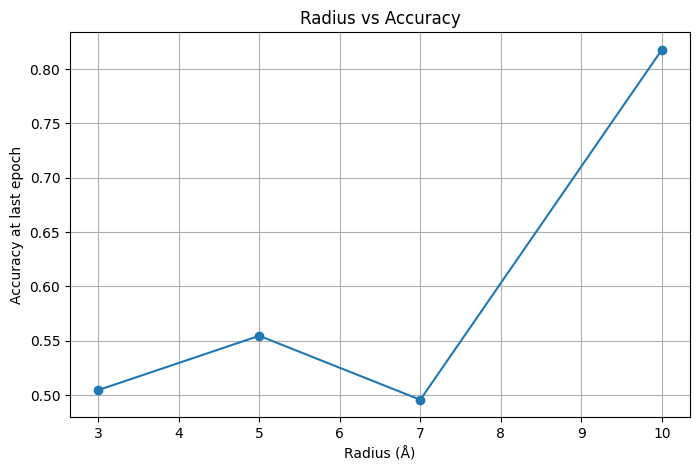

In [172]:
accuracies = [results[r][-1]['test_accuracy'] for r in rad]

plt.figure(figsize=(8,5))
plt.plot(rad, accuracies, marker='o', linestyle='-')
plt.title("Radius vs Accuracy")
plt.xlabel("Radius (Å)")
plt.ylabel("Accuracy at last epoch")
plt.grid(True)
plt.show()

In [147]:
pd.DataFrame.from_records(history)

,training_loss,test_accuracy,test_loss
0,0.680841,0.504444,0.690315
1,0.689572,0.777778,0.687409
2,0.682856,0.495556,0.685347
3,0.678392,0.495556,0.682595
4,0.681313,0.847778,0.674024
5,0.687017,0.504444,0.669353
6,0.680379,0.495556,0.662195
7,0.610610,0.807778,0.640018
8,0.626221,0.898889,0.618246
9,0.523307,0.832222,0.592547


In [158]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

dct = []
for r in rad:
    for epoch, statistics in enumerate(results[r]):
        dct.append({
            "Radius": r,
            "Epoch": epoch + 1,
            "Training Loss": statistics['training_loss'],
            "Test Accuracy": statistics['test_accuracy'],
            "Test Loss": statistics['test_loss']
        })
df = pd.DataFrame(dct)
df

,Radius,Epoch,Training Loss,Test Accuracy,Test Loss
0,4.0,1,0.685562,0.495556,0.693434
1,4.0,2,0.692679,0.504444,0.692528
2,4.0,3,0.699398,0.495556,0.693005
3,4.0,4,0.697878,0.495556,0.692549
4,4.0,5,0.692655,0.495556,0.692737
5,4.0,6,0.685865,0.495556,0.692531
6,4.0,7,0.692812,0.495556,0.692611
7,4.0,8,0.689052,0.504444,0.692318
8,4.0,9,0.675294,0.504444,0.692319
9,4.0,10,0.688565,0.504444,0.692271


In [ ]:
CHANGE: name="resid 613:754 and name CA N C", using only late simulations, seems to be overfitting due to less frame
    training_loss	test_accuracy	test_loss
0	0.562374	0.513333	0.701102
1	0.773349	0.486667	0.697791
2	0.666513	0.513333	0.679378
3	0.647404	1.000000	0.628916
4	0.648872	0.880000	0.547223
5	0.952839	0.486667	0.697130
6	0.435232	0.513333	0.619875
7	0.790622	0.520000	0.593141
8	0.418558	0.960000	0.462943
9	0.398797	0.973333	0.369488
10	0.340233	0.996667	0.332881
11	0.358396	0.956667	0.360120
12	0.435258	0.933333	0.424054
13	0.348645	0.940000	0.369302
14	0.332083	0.953333	0.356997

CHANGE: full simulations, good results
	training_loss	test_accuracy	test_loss
0	0.687883	0.504444	0.692985
1	0.692517	0.775556	0.691353
2	0.623324	0.640000	0.645995
3	0.506090	0.715556	0.582715
4	0.450717	0.816667	0.498017
5	0.439360	0.824444	0.476845
6	0.345354	0.784444	0.513226
7	0.418391	0.868889	0.436025
8	0.495380	0.842222	0.459707
9	0.314470	0.851111	0.461644
10	0.332093	0.878889	0.427020
11	0.313264	0.864444	0.444329
12	0.425179	0.868889	0.439064
13	0.313262	0.871111	0.438460
14	0.313262	0.913333	0.400578

CHANGE: selection_string="name CA N C", overfitting again
    training_loss	test_accuracy	test_loss
0	0.735092	0.486667	0.696513
1	0.708488	0.486667	0.693901
2	0.706887	0.486667	0.693386
3	0.692634	0.816667	0.690270
4	0.714058	0.486667	0.685859
5	0.655526	1.000000	0.654628
6	0.459406	0.513333	0.678026
7	0.898791	0.486667	0.685773
8	0.539527	0.516667	0.616767
9	0.522720	1.000000	0.520270
10	0.448007	1.000000	0.422417
11	0.491533	0.956667	0.414164
12	0.380476	0.933333	0.413461
13	0.475997	0.923333	0.400632
14	0.339070	0.980000	0.331706

CHANGE: full simulations, again good results overall
	training_loss	test_accuracy	test_loss
0	0.668922	0.504444	0.693878
1	0.677463	0.504444	0.693290
2	0.686212	0.504444	0.692931
3	0.691666	0.883333	0.690652
4	0.710071	0.495556	0.677894
5	0.681075	0.676667	0.627501
6	0.480222	0.577778	0.646426
7	0.638620	0.811111	0.512025
8	0.389760	0.802222	0.502694
9	0.331251	0.844444	0.446716
10	0.361563	0.780000	0.526556
11	0.509104	0.950000	0.364194
12	0.725616	0.856667	0.457344
13	0.359480	0.953333	0.356307
14	0.313727	0.883333	0.424348


In [ ]:
BEST PARAMETERS WITH BACKBONE ONLY AND ALL SIMULATIONS

	training_loss	test_accuracy	test_loss
0	0.668922	0.504444	0.693878
1	0.677463	0.504444	0.693290
2	0.686212	0.504444	0.692931
3	0.691666	0.883333	0.690652
4	0.710071	0.495556	0.677894
5	0.681075	0.676667	0.627501
6	0.480222	0.577778	0.646426
7	0.638620	0.811111	0.512025
8	0.389760	0.802222	0.502694
9	0.331251	0.844444	0.446716
10	0.361563	0.780000	0.526556
11	0.509104	0.950000	0.364194
12	0.725616	0.856667	0.457344
13	0.359480	0.953333	0.356307
14	0.313727	0.883333	0.424348

    training_loss	test_accuracy	test_loss
0	0.680344	0.504444	0.693183
1	0.699835	0.495556	0.693355
2	0.686886	0.504444	0.692958
3	0.695822	0.495556	0.692385
4	0.699984	0.612222	0.682742
5	0.809623	0.554444	0.677191
6	0.575478	0.603333	0.637775
7	0.535820	0.597778	0.633922
8	0.519799	0.642222	0.605968
9	0.671909	0.740000	0.546297
10	0.537757	0.807778	0.482531
11	0.618879	0.802222	0.485920
12	0.522704	0.901111	0.426193
13	0.349585	0.918889	0.406327
14	0.452205	0.890000	0.420723


In [ ]:
BACKBONE 10 EPOCHS
Training for radius 3.0:
 10%|███████████▌                                                                                                       | 1/10 [01:36<14:25, 96.19s/it]
Epoch  1 | Accuracy 0.5044
 20%|███████████████████████                                                                                            | 2/10 [03:12<12:47, 95.97s/it]
Epoch  2 | Accuracy 0.5044
 30%|██████████████████████████████████▌                                                                                | 3/10 [04:49<11:16, 96.68s/it]
Epoch  3 | Accuracy 0.5044
 40%|█████████████████████████████████████████████▌                                                                    | 4/10 [06:34<10:00, 100.02s/it]
Epoch  4 | Accuracy 0.4956
 50%|█████████████████████████████████████████████████████████                                                         | 5/10 [08:32<08:52, 106.57s/it]
Epoch  5 | Accuracy 0.5044
 60%|████████████████████████████████████████████████████████████████████▍                                             | 6/10 [10:38<07:32, 113.02s/it]
Epoch  6 | Accuracy 0.5044
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 7/10 [12:50<05:57, 119.11s/it]
Epoch  7 | Accuracy 0.5044
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 8/10 [15:08<04:10, 125.19s/it]
Epoch  8 | Accuracy 0.5044
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [17:27<02:09, 129.62s/it]
Epoch  9 | Accuracy 0.4956
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [19:52<00:00, 119.29s/it]
Epoch 10 | Accuracy 0.4956
================================
Training for radius 5.0:
 10%|███████████▍                                                                                                      | 1/10 [03:01<27:17, 181.95s/it]
Epoch  1 | Accuracy 0.4956
 20%|██████████████████████▊                                                                                           | 2/10 [06:04<24:16, 182.06s/it]
Epoch  2 | Accuracy 0.4956
 30%|██████████████████████████████████▏                                                                               | 3/10 [08:55<20:41, 177.40s/it]
Epoch  3 | Accuracy 0.5044
 40%|█████████████████████████████████████████████▌                                                                    | 4/10 [11:50<17:36, 176.12s/it]
Epoch  4 | Accuracy 0.4956
 50%|█████████████████████████████████████████████████████████                                                         | 5/10 [14:52<14:51, 178.26s/it]
Epoch  5 | Accuracy 0.4956
 60%|████████████████████████████████████████████████████████████████████▍                                             | 6/10 [17:56<12:01, 180.26s/it]
Epoch  6 | Accuracy 0.5044
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 7/10 [21:04<09:08, 182.71s/it]
Epoch  7 | Accuracy 0.4956
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 8/10 [24:14<06:10, 185.33s/it]
Epoch  8 | Accuracy 0.4956
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [27:30<03:08, 188.45s/it]
Epoch  9 | Accuracy 0.4956
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [30:53<00:00, 185.36s/it]
Epoch 10 | Accuracy 0.4956
================================
Training for radius 7.0:
 10%|███████████▍                                                                                                      | 1/10 [05:54<53:12, 354.75s/it]
Epoch  1 | Accuracy 0.5044
 20%|██████████████████████▊                                                                                           | 2/10 [11:52<47:32, 356.50s/it]
Epoch  2 | Accuracy 0.5044
 30%|██████████████████████████████████▏                                                                               | 3/10 [17:50<41:41, 357.34s/it]
Epoch  3 | Accuracy 0.4956
 40%|█████████████████████████████████████████████▌                                                                    | 4/10 [23:59<36:10, 361.73s/it]
Epoch  4 | Accuracy 0.4956
 50%|█████████████████████████████████████████████████████████                                                         | 5/10 [30:19<30:42, 368.54s/it]
Epoch  5 | Accuracy 0.4956
 60%|████████████████████████████████████████████████████████████████████▍                                             | 6/10 [36:36<24:45, 371.37s/it]
Epoch  6 | Accuracy 0.5044
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 7/10 [43:01<18:47, 375.86s/it]
Epoch  7 | Accuracy 0.4956
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 8/10 [49:32<12:41, 380.72s/it]
Epoch  8 | Accuracy 0.5044
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [56:05<06:24, 384.36s/it]
Epoch  9 | Accuracy 0.4956
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:02:47<00:00, 376.70s/it]
Epoch 10 | Accuracy 0.5044
================================
Training for radius 10.0:
 10%|███████████▏                                                                                                    | 1/10 [07:49<1:10:23, 469.26s/it]
Epoch  1 | Accuracy 0.4956
 20%|██████████████████████▍                                                                                         | 2/10 [15:36<1:02:25, 468.25s/it]
Epoch  2 | Accuracy 0.5044
 30%|██████████████████████████████████▏                                                                               | 3/10 [23:27<54:44, 469.22s/it]
Epoch  3 | Accuracy 0.8022
 40%|█████████████████████████████████████████████▌                                                                    | 4/10 [31:27<47:22, 473.78s/it]
Epoch  4 | Accuracy 0.5044
 50%|█████████████████████████████████████████████████████████                                                         | 5/10 [39:38<39:58, 479.77s/it]
Epoch  5 | Accuracy 0.4956
 60%|████████████████████████████████████████████████████████████████████▍                                             | 6/10 [47:55<32:23, 485.84s/it]
Epoch  6 | Accuracy 0.4978
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 7/10 [56:21<24:36, 492.27s/it]
Epoch  7 | Accuracy 0.5467
 80%|█████████████████████████████████████████████████████████████████████████████████████████▌                      | 8/10 [1:04:55<16:38, 499.33s/it]
Epoch  8 | Accuracy 0.5144
 90%|████████████████████████████████████████████████████████████████████████████████████████████████████▊           | 9/10 [1:13:35<08:25, 505.72s/it]
Epoch  9 | Accuracy 0.7911
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:22:16<00:00, 493.61s/it]
Epoch 10 | Accuracy 0.7789
================================

In [ ]:
MD2 BACKBONE 10 EPOCHS
Training for radius 3.0:
 10%|███████████▌                                                                                                       | 1/10 [00:22<03:20, 22.32s/it]
Epoch  1 | Accuracy 0.5044
 20%|███████████████████████                                                                                            | 2/10 [00:44<02:56, 22.02s/it]
Epoch  2 | Accuracy 0.5044
 30%|██████████████████████████████████▌                                                                                | 3/10 [01:06<02:33, 21.99s/it]
Epoch  3 | Accuracy 0.4956
 40%|██████████████████████████████████████████████                                                                     | 4/10 [01:30<02:17, 22.84s/it]
Epoch  4 | Accuracy 0.5044
 50%|█████████████████████████████████████████████████████████▌                                                         | 5/10 [01:55<01:59, 23.86s/it]
Epoch  5 | Accuracy 0.4956
 60%|█████████████████████████████████████████████████████████████████████                                              | 6/10 [02:23<01:40, 25.12s/it]
Epoch  6 | Accuracy 0.4956
 70%|████████████████████████████████████████████████████████████████████████████████▌                                  | 7/10 [02:51<01:18, 26.23s/it]
Epoch  7 | Accuracy 0.5044
 80%|████████████████████████████████████████████████████████████████████████████████████████████                       | 8/10 [03:21<00:54, 27.40s/it]
Epoch  8 | Accuracy 0.4956
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [03:53<00:28, 28.60s/it]
Epoch  9 | Accuracy 0.5044
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [04:26<00:00, 26.62s/it]
Epoch 10 | Accuracy 0.4956
================================
Training for radius 5.0:
 10%|███████████▌                                                                                                       | 1/10 [00:33<04:58, 33.14s/it]
Epoch  1 | Accuracy 0.5044
 20%|███████████████████████                                                                                            | 2/10 [01:06<04:27, 33.39s/it]
Epoch  2 | Accuracy 0.4956
 30%|██████████████████████████████████▌                                                                                | 3/10 [01:39<03:51, 33.08s/it]
Epoch  3 | Accuracy 0.4956
 40%|██████████████████████████████████████████████                                                                     | 4/10 [02:14<03:23, 33.94s/it]
Epoch  4 | Accuracy 0.4956
 50%|█████████████████████████████████████████████████████████▌                                                         | 5/10 [02:51<02:55, 35.16s/it]
Epoch  5 | Accuracy 0.5044
 60%|█████████████████████████████████████████████████████████████████████                                              | 6/10 [03:30<02:24, 36.14s/it]
Epoch  6 | Accuracy 0.5011
 70%|████████████████████████████████████████████████████████████████████████████████▌                                  | 7/10 [04:09<01:51, 37.26s/it]
Epoch  7 | Accuracy 0.5044
 80%|████████████████████████████████████████████████████████████████████████████████████████████                       | 8/10 [04:49<01:16, 38.25s/it]
Epoch  8 | Accuracy 0.5044
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [05:30<00:39, 39.06s/it]
Epoch  9 | Accuracy 0.5056
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [06:12<00:00, 37.26s/it]
Epoch 10 | Accuracy 0.4956
================================
Training for radius 7.0:
 10%|███████████▌                                                                                                       | 1/10 [00:53<08:03, 53.70s/it]
Epoch  1 | Accuracy 0.5044
 20%|███████████████████████                                                                                            | 2/10 [01:47<07:10, 53.85s/it]
Epoch  2 | Accuracy 0.4956
 30%|██████████████████████████████████▌                                                                                | 3/10 [02:41<06:15, 53.68s/it]
Epoch  3 | Accuracy 0.5044
 40%|██████████████████████████████████████████████                                                                     | 4/10 [03:36<05:26, 54.40s/it]
Epoch  4 | Accuracy 0.5211
 50%|█████████████████████████████████████████████████████████▌                                                         | 5/10 [04:34<04:37, 55.51s/it]
Epoch  5 | Accuracy 0.8222
 60%|█████████████████████████████████████████████████████████████████████                                              | 6/10 [05:33<03:47, 56.97s/it]
Epoch  6 | Accuracy 0.6833
 70%|████████████████████████████████████████████████████████████████████████████████▌                                  | 7/10 [06:36<02:55, 58.66s/it]
Epoch  7 | Accuracy 0.9456
 80%|████████████████████████████████████████████████████████████████████████████████████████████                       | 8/10 [07:39<02:00, 60.17s/it]
Epoch  8 | Accuracy 0.9900
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [08:44<01:01, 61.68s/it]
Epoch  9 | Accuracy 0.9878
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [09:52<00:00, 59.30s/it]
Epoch 10 | Accuracy 0.9900
================================
Training for radius 10.0:
 10%|███████████▌                                                                                                       | 1/10 [01:09<10:26, 69.61s/it]
Epoch  1 | Accuracy 0.4967
 20%|███████████████████████                                                                                            | 2/10 [02:17<09:08, 68.60s/it]
Epoch  2 | Accuracy 0.8733
 30%|██████████████████████████████████▌                                                                                | 3/10 [03:25<07:58, 68.43s/it]
Epoch  3 | Accuracy 0.6056
 40%|██████████████████████████████████████████████                                                                     | 4/10 [04:36<06:56, 69.35s/it]
Epoch  4 | Accuracy 0.8844
 50%|█████████████████████████████████████████████████████████▌                                                         | 5/10 [05:51<05:57, 71.49s/it]
Epoch  5 | Accuracy 0.8589
 60%|█████████████████████████████████████████████████████████████████████                                              | 6/10 [07:07<04:51, 72.90s/it]
Epoch  6 | Accuracy 0.8856
 70%|████████████████████████████████████████████████████████████████████████████████▌                                  | 7/10 [08:26<03:44, 74.81s/it]
Epoch  7 | Accuracy 0.9156
 80%|████████████████████████████████████████████████████████████████████████████████████████████                       | 8/10 [09:46<02:33, 76.66s/it]
Epoch  8 | Accuracy 0.9022
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [11:09<01:18, 78.46s/it]
Epoch  9 | Accuracy 0.9300
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [12:33<00:00, 75.35s/it]
Epoch 10 | Accuracy 0.9422
================================


In [ ]:
BACKBONE 20 EPOCHS
Training for radius 3.0:
  5%|█████▊                                                                                                             | 1/20 [01:36<30:26, 96.13s/it]
Epoch  1 | Accuracy 0.4956
 10%|███████████▌                                                                                                       | 2/20 [03:12<28:48, 96.02s/it]
Epoch  2 | Accuracy 0.6144
 15%|█████████████████▎                                                                                                 | 3/20 [04:47<27:04, 95.56s/it]
Epoch  3 | Accuracy 0.4956
 20%|███████████████████████                                                                                            | 4/20 [06:31<26:24, 99.03s/it]
Epoch  4 | Accuracy 0.4956
 25%|████████████████████████████▌                                                                                     | 5/20 [08:24<26:03, 104.22s/it]
Epoch  5 | Accuracy 0.5044
 30%|██████████████████████████████████▏                                                                               | 6/20 [10:21<25:18, 108.47s/it]
Epoch  6 | Accuracy 0.4956
 35%|███████████████████████████████████████▉                                                                          | 7/20 [12:21<24:18, 112.21s/it]
Epoch  7 | Accuracy 0.5044
 40%|█████████████████████████████████████████████▌                                                                    | 8/20 [14:25<23:11, 115.95s/it]
Epoch  8 | Accuracy 0.4956
 45%|███████████████████████████████████████████████████▎                                                              | 9/20 [16:32<21:51, 119.27s/it]
Epoch  9 | Accuracy 0.5044
 50%|████████████████████████████████████████████████████████▌                                                        | 10/20 [18:40<20:20, 122.02s/it]
Epoch 10 | Accuracy 0.5044
 55%|██████████████████████████████████████████████████████████████▏                                                  | 11/20 [20:51<18:45, 125.01s/it]
Epoch 11 | Accuracy 0.5044
 60%|███████████████████████████████████████████████████████████████████▊                                             | 12/20 [23:08<17:08, 128.50s/it]
Epoch 12 | Accuracy 0.4956
 65%|█████████████████████████████████████████████████████████████████████████▍                                       | 13/20 [25:33<15:33, 133.39s/it]
Epoch 13 | Accuracy 0.4956
 70%|███████████████████████████████████████████████████████████████████████████████                                  | 14/20 [28:12<14:07, 141.20s/it]
Epoch 14 | Accuracy 0.5044
 75%|████████████████████████████████████████████████████████████████████████████████████▊                            | 15/20 [31:00<12:26, 149.29s/it]
Epoch 15 | Accuracy 0.4956
 80%|██████████████████████████████████████████████████████████████████████████████████████████▍                      | 16/20 [33:49<10:20, 155.25s/it]
Epoch 16 | Accuracy 0.4956
 85%|████████████████████████████████████████████████████████████████████████████████████████████████                 | 17/20 [37:04<08:21, 167.30s/it]
Epoch 17 | Accuracy 0.5044
 90%|█████████████████████████████████████████████████████████████████████████████████████████████████████▋           | 18/20 [40:47<06:07, 183.88s/it]
Epoch 18 | Accuracy 0.5044
 95%|███████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 19/20 [43:51<03:03, 183.98s/it]
Epoch 19 | Accuracy 0.4956
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [46:36<00:00, 139.80s/it]
Epoch 20 | Accuracy 0.5044
================================
Training for radius 5.0:
  5%|█████▋                                                                                                            | 1/20 [02:53<54:47, 173.04s/it]
Epoch  1 | Accuracy 0.4956
 10%|███████████▍                                                                                                      | 2/20 [05:45<51:53, 172.95s/it]
Epoch  2 | Accuracy 0.5044
 15%|█████████████████                                                                                                 | 3/20 [08:39<49:06, 173.31s/it]
Epoch  3 | Accuracy 0.4956
 20%|██████████████████████▊                                                                                           | 4/20 [11:44<47:24, 177.79s/it]
Epoch  4 | Accuracy 0.4956
 25%|████████████████████████████▌                                                                                     | 5/20 [15:02<46:19, 185.31s/it]
Epoch  5 | Accuracy 0.4956
 30%|██████████████████████████████████▏                                                                               | 6/20 [18:26<44:39, 191.41s/it]
Epoch  6 | Accuracy 0.4956
 35%|███████████████████████████████████████▉                                                                          | 7/20 [21:53<42:36, 196.69s/it]
Epoch  7 | Accuracy 0.4956
 40%|█████████████████████████████████████████████▌                                                                    | 8/20 [25:27<40:23, 201.96s/it]
Epoch  8 | Accuracy 0.5044
 45%|███████████████████████████████████████████████████▎                                                              | 9/20 [29:03<37:51, 206.46s/it]
Epoch  9 | Accuracy 0.4956
 50%|████████████████████████████████████████████████████████▌                                                        | 10/20 [32:42<35:04, 210.41s/it]
Epoch 10 | Accuracy 0.4956
 55%|██████████████████████████████████████████████████████████████▏                                                  | 11/20 [36:32<32:26, 216.29s/it]
Epoch 11 | Accuracy 0.4956
 60%|███████████████████████████████████████████████████████████████████▊                                             | 12/20 [40:31<29:46, 223.36s/it]
Epoch 12 | Accuracy 0.4956
 65%|█████████████████████████████████████████████████████████████████████████▍                                       | 13/20 [44:47<27:12, 233.25s/it]
Epoch 13 | Accuracy 0.5044
 70%|███████████████████████████████████████████████████████████████████████████████                                  | 14/20 [49:31<24:50, 248.50s/it]
Epoch 14 | Accuracy 0.5044
 75%|████████████████████████████████████████████████████████████████████████████████████▊                            | 15/20 [54:47<22:23, 268.69s/it]
Epoch 15 | Accuracy 0.4956
 80%|████████████████████████████████████████████████████████████████████████████████████████▊                      | 16/20 [1:00:21<19:14, 288.58s/it]
Epoch 16 | Accuracy 0.4956
 85%|██████████████████████████████████████████████████████████████████████████████████████████████▎                | 17/20 [1:06:17<15:26, 308.71s/it]
Epoch 17 | Accuracy 0.4956
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████▉           | 18/20 [1:12:10<10:44, 322.16s/it]
Epoch 18 | Accuracy 0.4956
 95%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▍     | 19/20 [1:17:17<05:17, 317.40s/it]
Epoch 19 | Accuracy 0.5044
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [1:21:47<00:00, 245.39s/it]
Epoch 20 | Accuracy 0.5544
================================
Training for radius 7.0:
  5%|█████▌                                                                                                          | 1/20 [06:06<1:55:55, 366.10s/it]
Epoch  1 | Accuracy 0.5044
 10%|███████████▏                                                                                                    | 2/20 [12:10<1:49:28, 364.89s/it]
Epoch  2 | Accuracy 0.5044
 15%|████████████████▊                                                                                               | 3/20 [18:16<1:43:34, 365.56s/it]
Epoch  3 | Accuracy 0.4956
 20%|██████████████████████▍                                                                                         | 4/20 [24:31<1:38:31, 369.44s/it]
Epoch  4 | Accuracy 0.4956
 25%|████████████████████████████                                                                                    | 5/20 [30:58<1:33:53, 375.60s/it]
Epoch  5 | Accuracy 0.5044
 30%|█████████████████████████████████▌                                                                              | 6/20 [37:36<1:29:24, 383.17s/it]
Epoch  6 | Accuracy 0.4956
 35%|███████████████████████████████████████▏                                                                        | 7/20 [44:18<1:24:24, 389.54s/it]
Epoch  7 | Accuracy 0.4956
 40%|████████████████████████████████████████████▊                                                                   | 8/20 [51:08<1:19:09, 395.82s/it]
Epoch  8 | Accuracy 0.4956
 45%|██████████████████████████████████████████████████▍                                                             | 9/20 [58:03<1:13:41, 401.94s/it]
Epoch  9 | Accuracy 0.4956
 50%|██████████████████████████████████████████████████████▌                                                      | 10/20 [1:04:59<1:07:42, 406.23s/it]
Epoch 10 | Accuracy 0.4956
 55%|███████████████████████████████████████████████████████████▉                                                 | 11/20 [1:12:16<1:02:20, 415.65s/it]
Epoch 11 | Accuracy 0.4956
 60%|██████████████████████████████████████████████████████████████████▌                                            | 12/20 [1:19:42<56:40, 425.04s/it]
Epoch 12 | Accuracy 0.4956
 65%|████████████████████████████████████████████████████████████████████████▏                                      | 13/20 [1:27:27<50:59, 437.00s/it]
Epoch 13 | Accuracy 0.5044
 70%|█████████████████████████████████████████████████████████████████████████████▋                                 | 14/20 [1:35:18<44:43, 447.27s/it]
Epoch 14 | Accuracy 0.4956
 75%|███████████████████████████████████████████████████████████████████████████████████▎                           | 15/20 [1:43:18<38:05, 457.09s/it]
Epoch 15 | Accuracy 0.4956
 80%|████████████████████████████████████████████████████████████████████████████████████████▊                      | 16/20 [1:50:50<30:22, 455.56s/it]
Epoch 16 | Accuracy 0.5044
 85%|██████████████████████████████████████████████████████████████████████████████████████████████▎                | 17/20 [1:59:19<23:35, 471.74s/it]
Epoch 17 | Accuracy 0.5044
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████▉           | 18/20 [2:08:12<16:20, 490.01s/it]
Epoch 18 | Accuracy 0.7522
 95%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▍     | 19/20 [2:15:42<07:58, 478.01s/it]
Epoch 19 | Accuracy 0.5044
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [2:22:57<00:00, 428.89s/it]
Epoch 20 | Accuracy 0.4956
================================
Training for radius 10.0:
  5%|█████▌                                                                                                          | 1/20 [07:49<2:28:32, 469.06s/it]
Epoch  1 | Accuracy 0.4956
 10%|███████████▏                                                                                                    | 2/20 [15:40<2:21:05, 470.30s/it]
Epoch  2 | Accuracy 0.4956
 15%|████████████████▊                                                                                               | 3/20 [23:31<2:13:19, 470.59s/it]
Epoch  3 | Accuracy 0.5033
 20%|██████████████████████▍                                                                                         | 4/20 [31:30<2:06:25, 474.11s/it]
Epoch  4 | Accuracy 0.5044
 25%|████████████████████████████                                                                                    | 5/20 [39:39<1:59:53, 479.54s/it]
Epoch  5 | Accuracy 0.5056
 30%|█████████████████████████████████▌                                                                              | 6/20 [47:59<1:53:27, 486.22s/it]
Epoch  6 | Accuracy 0.8033
 35%|███████████████████████████████████████▏                                                                        | 7/20 [56:21<1:46:30, 491.56s/it]
Epoch  7 | Accuracy 0.5089
 40%|████████████████████████████████████████████                                                                  | 8/20 [1:04:50<1:39:24, 497.03s/it]
Epoch  8 | Accuracy 0.5044
 45%|█████████████████████████████████████████████████▌                                                            | 9/20 [1:13:28<1:32:20, 503.65s/it]
Epoch  9 | Accuracy 0.5067
 50%|██████████████████████████████████████████████████████▌                                                      | 10/20 [1:22:18<1:25:17, 511.71s/it]
Epoch 10 | Accuracy 0.5400
 55%|███████████████████████████████████████████████████████████▉                                                 | 11/20 [1:31:13<1:17:49, 518.81s/it]
Epoch 11 | Accuracy 0.5289
 60%|█████████████████████████████████████████████████████████████████▍                                           | 12/20 [1:40:15<1:10:08, 526.10s/it]
Epoch 12 | Accuracy 0.7956
 65%|██████████████████████████████████████████████████████████████████████▊                                      | 13/20 [1:49:20<1:02:01, 531.63s/it]
Epoch 13 | Accuracy 0.5167
 70%|█████████████████████████████████████████████████████████████████████████████▋                                 | 14/20 [1:58:31<53:44, 537.41s/it]
Epoch 14 | Accuracy 0.7911
 75%|███████████████████████████████████████████████████████████████████████████████████▎                           | 15/20 [2:08:00<45:35, 547.02s/it]
Epoch 15 | Accuracy 0.4967
 80%|████████████████████████████████████████████████████████████████████████████████████████▊                      | 16/20 [2:18:00<37:31, 562.85s/it]
Epoch 16 | Accuracy 0.7922
 85%|██████████████████████████████████████████████████████████████████████████████████████████████▎                | 17/20 [2:28:37<29:15, 585.33s/it]
Epoch 17 | Accuracy 0.7478
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████▉           | 18/20 [2:39:45<20:20, 610.16s/it]
Epoch 18 | Accuracy 0.8222
 95%|█████████████████████████████████████████████████████████████████████████████████████████████████████████▍     | 19/20 [2:49:32<10:03, 603.04s/it]
Epoch 19 | Accuracy 0.8133
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [2:58:34<00:00, 535.75s/it]
Epoch 20 | Accuracy 0.8178
================================

In [ ]:
FINAL ONE MD2 BACKBONE 20 EPOCHS
Training for radius 3.0:
  5%|█████▊                                                                                                             | 1/20 [00:21<06:56, 21.93s/it]
Epoch  1 | Accuracy 0.5044
 10%|███████████▌                                                                                                       | 2/20 [00:44<06:43, 22.42s/it]
Epoch  2 | Accuracy 0.5044
 15%|█████████████████▎                                                                                                 | 3/20 [01:07<06:23, 22.53s/it]
Epoch  3 | Accuracy 0.5044
 20%|███████████████████████                                                                                            | 4/20 [01:32<06:18, 23.68s/it]
Epoch  4 | Accuracy 0.5044
 25%|████████████████████████████▊                                                                                      | 5/20 [02:00<06:18, 25.21s/it]
Epoch  5 | Accuracy 0.4956
 30%|██████████████████████████████████▌                                                                                | 6/20 [02:30<06:15, 26.80s/it]
Epoch  6 | Accuracy 0.4956
 35%|████████████████████████████████████████▎                                                                          | 7/20 [03:02<06:10, 28.46s/it]
Epoch  7 | Accuracy 0.5044
 40%|██████████████████████████████████████████████                                                                     | 8/20 [03:35<05:58, 29.90s/it]
Epoch  8 | Accuracy 0.5044
 45%|███████████████████████████████████████████████████▊                                                               | 9/20 [04:09<05:42, 31.14s/it]
Epoch  9 | Accuracy 0.5044
 50%|█████████████████████████████████████████████████████████                                                         | 10/20 [04:43<05:21, 32.10s/it]
Epoch 10 | Accuracy 0.5044
 55%|██████████████████████████████████████████████████████████████▋                                                   | 11/20 [05:20<05:01, 33.54s/it]
Epoch 11 | Accuracy 0.5044
 60%|████████████████████████████████████████████████████████████████████▍                                             | 12/20 [05:58<04:38, 34.78s/it]
Epoch 12 | Accuracy 0.4956
 65%|██████████████████████████████████████████████████████████████████████████                                        | 13/20 [06:38<04:14, 36.42s/it]
Epoch 13 | Accuracy 0.4956
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 14/20 [07:21<03:50, 38.40s/it]
Epoch 14 | Accuracy 0.5044
 75%|█████████████████████████████████████████████████████████████████████████████████████▌                            | 15/20 [08:04<03:19, 39.84s/it]
Epoch 15 | Accuracy 0.4956
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 16/20 [08:53<02:50, 42.69s/it]
Epoch 16 | Accuracy 0.4956
 85%|████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 17/20 [09:46<02:17, 45.77s/it]
Epoch 17 | Accuracy 0.5044
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 18/20 [10:48<01:41, 50.63s/it]
Epoch 18 | Accuracy 0.5044
 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 19/20 [11:36<00:49, 49.71s/it]
Epoch 19 | Accuracy 0.5044
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [12:16<00:00, 36.82s/it]
Epoch 20 | Accuracy 0.5044
================================
Training for radius 5.0:
  5%|█████▊                                                                                                             | 1/20 [00:33<10:42, 33.81s/it]
Epoch  1 | Accuracy 0.5044
 10%|███████████▌                                                                                                       | 2/20 [01:06<09:56, 33.15s/it]
Epoch  2 | Accuracy 0.7967
 15%|█████████████████▎                                                                                                 | 3/20 [01:39<09:20, 32.98s/it]
Epoch  3 | Accuracy 0.4956
 20%|███████████████████████                                                                                            | 4/20 [02:14<09:02, 33.94s/it]
Epoch  4 | Accuracy 0.4956
 25%|████████████████████████████▊                                                                                      | 5/20 [02:50<08:40, 34.71s/it]
Epoch  5 | Accuracy 0.5667
 30%|██████████████████████████████████▌                                                                                | 6/20 [03:26<08:12, 35.17s/it]
Epoch  6 | Accuracy 0.7156
 35%|████████████████████████████████████████▎                                                                          | 7/20 [04:03<07:45, 35.80s/it]
Epoch  7 | Accuracy 0.4956
 40%|██████████████████████████████████████████████                                                                     | 8/20 [04:41<07:17, 36.46s/it]
Epoch  8 | Accuracy 0.4967
 45%|███████████████████████████████████████████████████▊                                                               | 9/20 [05:19<06:43, 36.72s/it]
Epoch  9 | Accuracy 0.6722
 50%|█████████████████████████████████████████████████████████                                                         | 10/20 [05:57<06:12, 37.28s/it]
Epoch 10 | Accuracy 0.6900
 55%|██████████████████████████████████████████████████████████████▋                                                   | 11/20 [06:37<05:42, 38.01s/it]
Epoch 11 | Accuracy 0.6189
 60%|████████████████████████████████████████████████████████████████████▍                                             | 12/20 [07:18<05:12, 39.03s/it]
Epoch 12 | Accuracy 0.8444
 65%|██████████████████████████████████████████████████████████████████████████                                        | 13/20 [08:01<04:41, 40.21s/it]
Epoch 13 | Accuracy 0.6522
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 14/20 [08:46<04:10, 41.69s/it]
Epoch 14 | Accuracy 0.8856
 75%|█████████████████████████████████████████████████████████████████████████████████████▌                            | 15/20 [09:39<03:45, 45.05s/it]
Epoch 15 | Accuracy 0.7378
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 16/20 [10:36<03:14, 48.53s/it]
Epoch 16 | Accuracy 0.8567
 85%|████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 17/20 [11:37<02:37, 52.41s/it]
Epoch 17 | Accuracy 0.7544
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 18/20 [12:41<01:51, 55.74s/it]
Epoch 18 | Accuracy 0.8789
 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 19/20 [13:34<00:54, 54.97s/it]
Epoch 19 | Accuracy 0.8900
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [14:19<00:00, 42.95s/it]
Epoch 20 | Accuracy 0.8989
================================
Training for radius 7.0:
  5%|█████▊                                                                                                             | 1/20 [00:54<17:06, 54.05s/it]
Epoch  1 | Accuracy 0.5067
 10%|███████████▌                                                                                                       | 2/20 [01:49<16:26, 54.79s/it]
Epoch  2 | Accuracy 0.4956
 15%|█████████████████▎                                                                                                 | 3/20 [02:44<15:34, 54.97s/it]
Epoch  3 | Accuracy 0.9889
 20%|███████████████████████                                                                                            | 4/20 [03:43<15:06, 56.65s/it]
Epoch  4 | Accuracy 0.5044
 25%|████████████████████████████▊                                                                                      | 5/20 [04:45<14:38, 58.55s/it]
Epoch  5 | Accuracy 0.9889
 30%|██████████████████████████████████▌                                                                                | 6/20 [05:49<14:04, 60.34s/it]
Epoch  6 | Accuracy 0.4956
 35%|████████████████████████████████████████▎                                                                          | 7/20 [06:53<13:21, 61.69s/it]
Epoch  7 | Accuracy 0.6933
 40%|██████████████████████████████████████████████                                                                     | 8/20 [08:00<12:37, 63.15s/it]
Epoch  8 | Accuracy 0.8700
 45%|███████████████████████████████████████████████████▊                                                               | 9/20 [09:07<11:50, 64.55s/it]
Epoch  9 | Accuracy 0.9511
 50%|█████████████████████████████████████████████████████████                                                         | 10/20 [10:15<10:56, 65.63s/it]
Epoch 10 | Accuracy 0.9778
 55%|██████████████████████████████████████████████████████████████▋                                                   | 11/20 [11:26<10:05, 67.26s/it]
Epoch 11 | Accuracy 0.9867
 60%|████████████████████████████████████████████████████████████████████▍                                             | 12/20 [12:40<09:13, 69.15s/it]
Epoch 12 | Accuracy 0.9889
 65%|██████████████████████████████████████████████████████████████████████████                                        | 13/20 [13:55<08:16, 70.87s/it]
Epoch 13 | Accuracy 0.9944
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 14/20 [15:11<07:15, 72.52s/it]
Epoch 14 | Accuracy 0.9933
 75%|█████████████████████████████████████████████████████████████████████████████████████▌                            | 15/20 [16:33<06:16, 75.24s/it]
Epoch 15 | Accuracy 0.9711
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 16/20 [17:58<05:13, 78.29s/it]
Epoch 16 | Accuracy 0.9944
 85%|████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 17/20 [19:30<04:06, 82.33s/it]
Epoch 17 | Accuracy 0.9922
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 18/20 [21:06<02:53, 86.68s/it]
Epoch 18 | Accuracy 0.9956
 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 19/20 [22:30<01:25, 85.89s/it]
Epoch 19 | Accuracy 0.9944
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [23:52<00:00, 71.61s/it]
Epoch 20 | Accuracy 0.9944
================================
Training for radius 10.0:
  5%|█████▊                                                                                                             | 1/20 [01:11<22:43, 71.77s/it]
Epoch  1 | Accuracy 0.5044
 10%|███████████▌                                                                                                       | 2/20 [02:22<21:20, 71.11s/it]
Epoch  2 | Accuracy 0.8700
 15%|█████████████████▎                                                                                                 | 3/20 [03:33<20:10, 71.21s/it]
Epoch  3 | Accuracy 0.7978
 20%|███████████████████████                                                                                            | 4/20 [04:50<19:32, 73.30s/it]
Epoch  4 | Accuracy 0.8956
 25%|████████████████████████████▊                                                                                      | 5/20 [06:08<18:46, 75.11s/it]
Epoch  5 | Accuracy 0.9033
 30%|██████████████████████████████████▌                                                                                | 6/20 [07:28<17:56, 76.90s/it]
Epoch  6 | Accuracy 0.9178
 35%|████████████████████████████████████████▎                                                                          | 7/20 [08:51<17:03, 78.72s/it]
Epoch  7 | Accuracy 0.9244
 40%|██████████████████████████████████████████████                                                                     | 8/20 [10:13<15:56, 79.73s/it]
Epoch  8 | Accuracy 0.9322
 45%|███████████████████████████████████████████████████▊                                                               | 9/20 [11:37<14:51, 81.01s/it]
Epoch  9 | Accuracy 0.9311
 50%|█████████████████████████████████████████████████████████                                                         | 10/20 [13:04<13:50, 83.03s/it]
Epoch 10 | Accuracy 0.9444
 55%|██████████████████████████████████████████████████████████████▋                                                   | 11/20 [14:31<12:36, 84.07s/it]
Epoch 11 | Accuracy 0.9433
 60%|████████████████████████████████████████████████████████████████████▍                                             | 12/20 [16:00<11:25, 85.74s/it]
Epoch 12 | Accuracy 0.9489
 65%|██████████████████████████████████████████████████████████████████████████                                        | 13/20 [17:30<10:08, 86.96s/it]
Epoch 13 | Accuracy 0.9556
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 14/20 [19:03<08:52, 88.79s/it]
Epoch 14 | Accuracy 0.9589
 75%|█████████████████████████████████████████████████████████████████████████████████████▌                            | 15/20 [20:43<07:40, 92.09s/it]
Epoch 15 | Accuracy 0.9644
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 16/20 [22:29<06:25, 96.39s/it]
Epoch 16 | Accuracy 0.9667
 85%|████████████████████████████████████████████████████████████████████████████████████████████████                 | 17/20 [24:21<05:02, 100.92s/it]
Epoch 17 | Accuracy 0.9700
 90%|█████████████████████████████████████████████████████████████████████████████████████████████████████▋           | 18/20 [26:13<03:28, 104.34s/it]
Epoch 18 | Accuracy 0.9689
 95%|███████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 19/20 [27:53<01:43, 103.03s/it]
Epoch 19 | Accuracy 0.9744
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [29:25<00:00, 88.27s/it]
Epoch 20 | Accuracy 0.9667
================================

In [ ]:
MD2 BACKBONE 20 EPOCHS NARROW R VALUES
Training for radius 4.0:
  5%|█████▊                                                                                                             | 1/20 [00:27<08:41, 27.46s/it]
Epoch  1 | Accuracy 0.4956
 10%|███████████▌                                                                                                       | 2/20 [00:54<08:06, 27.05s/it]
Epoch  2 | Accuracy 0.5044
 15%|█████████████████▎                                                                                                 | 3/20 [01:21<07:42, 27.22s/it]
Epoch  3 | Accuracy 0.4956
 20%|███████████████████████                                                                                            | 4/20 [01:49<07:22, 27.63s/it]
Epoch  4 | Accuracy 0.4956
 25%|████████████████████████████▊                                                                                      | 5/20 [02:21<07:15, 29.01s/it]
Epoch  5 | Accuracy 0.4956
 30%|██████████████████████████████████▌                                                                                | 6/20 [02:53<07:02, 30.18s/it]
Epoch  6 | Accuracy 0.4956
 35%|████████████████████████████████████████▎                                                                          | 7/20 [03:25<06:38, 30.65s/it]
Epoch  7 | Accuracy 0.4956
 40%|██████████████████████████████████████████████                                                                     | 8/20 [03:58<06:16, 31.39s/it]
Epoch  8 | Accuracy 0.5044
 45%|███████████████████████████████████████████████████▊                                                               | 9/20 [04:32<05:53, 32.14s/it]
Epoch  9 | Accuracy 0.5044
 50%|█████████████████████████████████████████████████████████                                                         | 10/20 [05:07<05:31, 33.12s/it]
Epoch 10 | Accuracy 0.5044
 55%|██████████████████████████████████████████████████████████████▋                                                   | 11/20 [05:45<05:12, 34.72s/it]
Epoch 11 | Accuracy 0.5044
 60%|████████████████████████████████████████████████████████████████████▍                                             | 12/20 [06:27<04:53, 36.69s/it]
Epoch 12 | Accuracy 0.4956
 65%|██████████████████████████████████████████████████████████████████████████                                        | 13/20 [07:10<04:32, 38.88s/it]
Epoch 13 | Accuracy 0.4956
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 14/20 [07:57<04:07, 41.28s/it]
Epoch 14 | Accuracy 0.5044
 75%|█████████████████████████████████████████████████████████████████████████████████████▌                            | 15/20 [08:47<03:38, 43.78s/it]
Epoch 15 | Accuracy 0.5044
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 16/20 [09:40<03:06, 46.72s/it]
Epoch 16 | Accuracy 0.5044
 85%|████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 17/20 [10:38<02:29, 49.95s/it]
Epoch 17 | Accuracy 0.4956
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 18/20 [11:42<01:48, 54.18s/it]
Epoch 18 | Accuracy 0.5044
 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 19/20 [12:32<00:52, 52.86s/it]
Epoch 19 | Accuracy 0.5044
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [13:13<00:00, 39.69s/it]
Epoch 20 | Accuracy 0.4956
================================
Training for radius 4.5:
  5%|█████▊                                                                                                             | 1/20 [00:28<09:08, 28.88s/it]
Epoch  1 | Accuracy 0.5044
 10%|███████████▌                                                                                                       | 2/20 [00:57<08:37, 28.73s/it]
Epoch  2 | Accuracy 0.8844
 15%|█████████████████▎                                                                                                 | 3/20 [01:25<08:06, 28.60s/it]
Epoch  3 | Accuracy 0.7778
 20%|███████████████████████                                                                                            | 4/20 [01:57<07:53, 29.62s/it]
Epoch  4 | Accuracy 0.5189
 25%|████████████████████████████▊                                                                                      | 5/20 [02:30<07:42, 30.83s/it]
Epoch  5 | Accuracy 0.5044
 30%|██████████████████████████████████▌                                                                                | 6/20 [03:04<07:27, 31.99s/it]
Epoch  6 | Accuracy 0.5044
 35%|████████████████████████████████████████▎                                                                          | 7/20 [03:39<07:10, 33.13s/it]
Epoch  7 | Accuracy 0.5044
 40%|██████████████████████████████████████████████                                                                     | 8/20 [04:16<06:49, 34.13s/it]
Epoch  8 | Accuracy 0.5056
 45%|███████████████████████████████████████████████████▊                                                               | 9/20 [04:53<06:26, 35.18s/it]
Epoch  9 | Accuracy 0.4956
 50%|█████████████████████████████████████████████████████████                                                         | 10/20 [05:32<06:03, 36.38s/it]
Epoch 10 | Accuracy 0.8911
 55%|██████████████████████████████████████████████████████████████▋                                                   | 11/20 [06:14<05:41, 37.97s/it]
Epoch 11 | Accuracy 0.4956
 60%|████████████████████████████████████████████████████████████████████▍                                             | 12/20 [06:56<05:14, 39.25s/it]
Epoch 12 | Accuracy 0.5044
 65%|██████████████████████████████████████████████████████████████████████████                                        | 13/20 [07:40<04:44, 40.68s/it]
Epoch 13 | Accuracy 0.9178
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 14/20 [08:27<04:15, 42.54s/it]
Epoch 14 | Accuracy 0.5089
 75%|█████████████████████████████████████████████████████████████████████████████████████▌                            | 15/20 [09:18<03:45, 45.16s/it]
Epoch 15 | Accuracy 0.5044
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 16/20 [10:13<03:12, 48.03s/it]
Epoch 16 | Accuracy 0.6478
 85%|████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 17/20 [11:08<02:31, 50.35s/it]
Epoch 17 | Accuracy 0.5044
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 18/20 [12:06<01:45, 52.62s/it]
Epoch 18 | Accuracy 0.5822
 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 19/20 [12:52<00:50, 50.40s/it]
Epoch 19 | Accuracy 0.7400
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [13:32<00:00, 40.62s/it]
Epoch 20 | Accuracy 0.8333
================================
Training for radius 5.0:
  5%|█████▊                                                                                                             | 1/20 [00:33<10:43, 33.86s/it]
Epoch  1 | Accuracy 0.5044
 10%|███████████▌                                                                                                       | 2/20 [01:07<10:02, 33.50s/it]
Epoch  2 | Accuracy 0.5044
 15%|█████████████████▎                                                                                                 | 3/20 [01:40<09:25, 33.24s/it]
Epoch  3 | Accuracy 0.6711
 20%|███████████████████████                                                                                            | 4/20 [02:16<09:13, 34.58s/it]
Epoch  4 | Accuracy 0.5044
 25%|████████████████████████████▊                                                                                      | 5/20 [02:56<09:05, 36.36s/it]
Epoch  5 | Accuracy 0.5044
 30%|██████████████████████████████████▌                                                                                | 6/20 [03:37<08:51, 37.95s/it]
Epoch  6 | Accuracy 0.4956
 35%|████████████████████████████████████████▎                                                                          | 7/20 [04:19<08:30, 39.27s/it]
Epoch  7 | Accuracy 0.8367
 40%|██████████████████████████████████████████████                                                                     | 8/20 [05:03<08:08, 40.74s/it]
Epoch  8 | Accuracy 0.6689
 45%|███████████████████████████████████████████████████▊                                                               | 9/20 [05:47<07:41, 41.98s/it]
Epoch  9 | Accuracy 0.7611
 50%|█████████████████████████████████████████████████████████                                                         | 10/20 [06:33<07:10, 43.02s/it]
Epoch 10 | Accuracy 0.8189
 55%|██████████████████████████████████████████████████████████████▋                                                   | 11/20 [07:19<06:36, 44.04s/it]
Epoch 11 | Accuracy 0.5211
 60%|████████████████████████████████████████████████████████████████████▍                                             | 12/20 [08:07<06:01, 45.19s/it]
Epoch 12 | Accuracy 0.8911
 65%|██████████████████████████████████████████████████████████████████████████                                        | 13/20 [08:56<05:25, 46.49s/it]
Epoch 13 | Accuracy 0.8933
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 14/20 [09:48<04:48, 48.05s/it]
Epoch 14 | Accuracy 0.8933
 75%|█████████████████████████████████████████████████████████████████████████████████████▌                            | 15/20 [10:42<04:08, 49.72s/it]
Epoch 15 | Accuracy 0.7656
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 16/20 [11:36<03:24, 51.19s/it]
Epoch 16 | Accuracy 0.8867
 85%|████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 17/20 [12:35<02:40, 53.52s/it]
Epoch 17 | Accuracy 0.8133
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 18/20 [13:40<01:53, 56.83s/it]
Epoch 18 | Accuracy 0.8933
 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 19/20 [14:34<00:56, 56.21s/it]
Epoch 19 | Accuracy 0.8633
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [15:22<00:00, 46.14s/it]
Epoch 20 | Accuracy 0.9033
================================
Training for radius 5.5:
  5%|█████▊                                                                                                             | 1/20 [00:38<12:17, 38.82s/it]
Epoch  1 | Accuracy 0.5044
 10%|███████████▌                                                                                                       | 2/20 [01:16<11:31, 38.40s/it]
Epoch  2 | Accuracy 0.7778
 15%|█████████████████▎                                                                                                 | 3/20 [01:56<11:01, 38.88s/it]
Epoch  3 | Accuracy 0.4956
 20%|███████████████████████                                                                                            | 4/20 [02:37<10:39, 39.94s/it]
Epoch  4 | Accuracy 0.4956
 25%|████████████████████████████▊                                                                                      | 5/20 [03:20<10:14, 40.96s/it]
Epoch  5 | Accuracy 0.8478
 30%|██████████████████████████████████▌                                                                                | 6/20 [04:06<09:54, 42.46s/it]
Epoch  6 | Accuracy 0.5044
 35%|████████████████████████████████████████▎                                                                          | 7/20 [04:52<09:27, 43.65s/it]
Epoch  7 | Accuracy 0.4956
 40%|██████████████████████████████████████████████                                                                     | 8/20 [05:40<09:03, 45.26s/it]
Epoch  8 | Accuracy 0.8078
 45%|███████████████████████████████████████████████████▊                                                               | 9/20 [06:31<08:36, 46.95s/it]
Epoch  9 | Accuracy 0.8989
 50%|█████████████████████████████████████████████████████████                                                         | 10/20 [07:21<08:00, 48.02s/it]
Epoch 10 | Accuracy 0.8322
 55%|██████████████████████████████████████████████████████████████▋                                                   | 11/20 [08:14<07:23, 49.25s/it]
Epoch 11 | Accuracy 0.8711
 60%|████████████████████████████████████████████████████████████████████▍                                             | 12/20 [09:09<06:48, 51.03s/it]
Epoch 12 | Accuracy 0.8044
 65%|██████████████████████████████████████████████████████████████████████████                                        | 13/20 [10:07<06:12, 53.20s/it]
Epoch 13 | Accuracy 0.8967
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 14/20 [11:10<05:37, 56.19s/it]
Epoch 14 | Accuracy 0.8667
 75%|█████████████████████████████████████████████████████████████████████████████████████▌                            | 15/20 [12:17<04:57, 59.50s/it]
Epoch 15 | Accuracy 0.8722
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 16/20 [13:28<04:11, 62.83s/it]
Epoch 16 | Accuracy 0.9044
 85%|████████████████████████████████████████████████████████████████████████████████████████████████▉                 | 17/20 [14:41<03:18, 66.12s/it]
Epoch 17 | Accuracy 0.9144
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 18/20 [15:57<02:18, 69.10s/it]
Epoch 18 | Accuracy 0.9167
 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████▎     | 19/20 [16:56<01:06, 66.07s/it]
Epoch 19 | Accuracy 0.9122
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [17:51<00:00, 53.57s/it]
Epoch 20 | Accuracy 0.9289
================================

Radius	Epoch	Training Loss	Test Accuracy	Test Loss

0	4.0	1	0.685562	0.495556	0.693434
1	4.0	2	0.692679	0.504444	0.692528
2	4.0	3	0.699398	0.495556	0.693005
3	4.0	4	0.697878	0.495556	0.692549
4	4.0	5	0.692655	0.495556	0.692737
5	4.0	6	0.685865	0.495556	0.692531
6	4.0	7	0.692812	0.495556	0.692611
7	4.0	8	0.689052	0.504444	0.692318
8	4.0	9	0.675294	0.504444	0.692319
9	4.0	10	0.688565	0.504444	0.692271
10	4.0	11	0.695811	0.504444	0.692202
11	4.0	12	0.687252	0.495556	0.692426
12	4.0	13	0.689699	0.495556	0.692513
13	4.0	14	0.694044	0.504444	0.692303
14	4.0	15	0.693042	0.504444	0.692452
15	4.0	16	0.692541	0.504444	0.692380
16	4.0	17	0.695524	0.495556	0.692568
17	4.0	18	0.689609	0.504444	0.692403
18	4.0	19	0.692902	0.504444	0.692454
19	4.0	20	0.693777	0.495556	0.692531

20	4.5	1	0.698235	0.504444	0.692078
21	4.5	2	0.691331	0.884444	0.691305
22	4.5	3	0.690185	0.777778	0.690639
23	4.5	4	0.687285	0.518889	0.690020
24	4.5	5	0.691923	0.504444	0.690523
25	4.5	6	0.699818	0.504444	0.689175
26	4.5	7	0.674624	0.504444	0.688213
27	4.5	8	0.683795	0.505556	0.687098
28	4.5	9	0.687939	0.495556	0.686824
29	4.5	10	0.688072	0.891111	0.684861
30	4.5	11	0.683013	0.495556	0.684504
31	4.5	12	0.678537	0.504444	0.685982
32	4.5	13	0.674098	0.917778	0.679218
33	4.5	14	0.680935	0.508889	0.677418
34	4.5	15	0.650572	0.504444	0.676064
35	4.5	16	0.674726	0.647778	0.670255
36	4.5	17	0.707145	0.504444	0.670567
37	4.5	18	0.662683	0.582222	0.662808
38	4.5	19	0.642855	0.740000	0.656033
39	4.5	20	0.683592	0.833333	0.650673

40	5.0	1	0.714296	0.504444	0.691259
41	5.0	2	0.698075	0.504444	0.689212
42	5.0	3	0.691891	0.671111	0.687394
43	5.0	4	0.662853	0.504444	0.686104
44	5.0	5	0.677771	0.504444	0.682917
45	5.0	6	0.701537	0.495556	0.681668
46	5.0	7	0.681851	0.836667	0.676094
47	5.0	8	0.692673	0.668889	0.671554
48	5.0	9	0.671264	0.761111	0.663965
49	5.0	10	0.654214	0.818889	0.654087
50	5.0	11	0.604578	0.521111	0.650348
51	5.0	12	0.626258	0.891111	0.625343
52	5.0	13	0.618833	0.893333	0.606230
53	5.0	14	0.601006	0.893333	0.583642
54	5.0	15	0.593106	0.765556	0.568772
55	5.0	16	0.527227	0.886667	0.527992
56	5.0	17	0.475507	0.813333	0.507391
57	5.0	18	0.410433	0.893333	0.464936
58	5.0	19	0.467015	0.863333	0.438229
59	5.0	20	0.371301	0.903333	0.405889

60	5.5	1	0.680841	0.504444	0.690315
61	5.5	2	0.689572	0.777778	0.687409
62	5.5	3	0.682856	0.495556	0.685347
63	5.5	4	0.678392	0.495556	0.682595
64	5.5	5	0.681313	0.847778	0.674024
65	5.5	6	0.687017	0.504444	0.669353
66	5.5	7	0.680379	0.495556	0.662195
67	5.5	8	0.610610	0.807778	0.640018
68	5.5	9	0.626221	0.898889	0.618246
69	5.5	10	0.523307	0.832222	0.592547
70	5.5	11	0.554819	0.871111	0.559481
71	5.5	12	0.496534	0.804444	0.527500
72	5.5	13	0.489483	0.896667	0.480135
73	5.5	14	0.375516	0.866667	0.446482
74	5.5	15	0.637129	0.872222	0.411250
75	5.5	16	0.301493	0.904444	0.366127
76	5.5	17	0.516728	0.914444	0.334781
77	5.5	18	0.407288	0.916667	0.311002
78	5.5	19	0.163406	0.912222	0.287702
79	5.5	20	0.327207	0.928889	0.262620